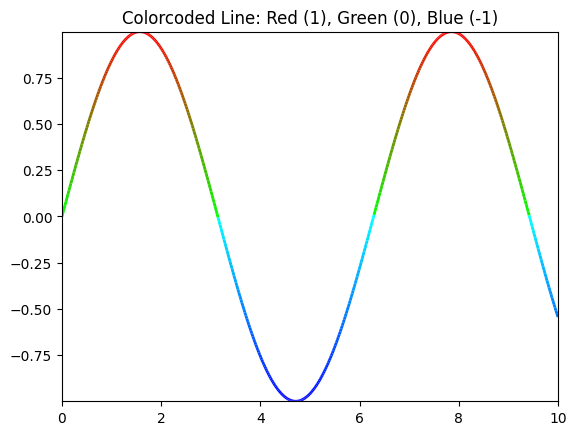

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# Example data
x = np.linspace(0, 10, 500)
y = np.sin(x)

# Create segments for LineCollection
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Define a custom colormap using RGB interpolation
def custom_colormap(val):
    """Maps val in [-1, 1] to RGB color (blue → green → red)."""
    val = np.clip(val, -1, 1)
    if val < 0:
        # interpolate between blue and green
        t = (val + 1) / 1  # from 0 (at -1) to 1 (at 0)
        return (0, t, 1)  # blend from blue (0,0,1) to green (0,1,0)
    else:
        # interpolate between green and red
        t = val / 1  # from 0 (at 0) to 1 (at 1)
        return (t, 1 - t, 0)  # blend from green (0,1,0) to red (1,0,0)

# Map each segment's average y-value to a color
colors = [custom_colormap((y[i] + y[i+1]) / 2) for i in range(len(y)-1)]

# Create line collection
lc = LineCollection(segments, colors=colors, linewidths=2)

# Plot
fig, ax = plt.subplots()
ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_title("Colorcoded Line: Red (1), Green (0), Blue (-1)")
plt.show()